Generating ground truth trajectories...
Successfully generated 120 valid trajectories.
Rejected 18 short trajectories during generation.
Created 8093 test samples from 120 trajectories
Model and weights loaded successfully!

Starting inference on 8093 chains...


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_50450/3359441362.py:140: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_input_sequence = torch.tensor(test_input, dtype=torch.float32)


Progress: 100/8093 chains (1.2%) | Speed: 130.2 chains/s | ETA: 61.4s
Progress: 200/8093 chains (2.5%) | Speed: 129.0 chains/s | ETA: 61.2s
Progress: 300/8093 chains (3.7%) | Speed: 120.3 chains/s | ETA: 64.8s
Progress: 400/8093 chains (4.9%) | Speed: 121.8 chains/s | ETA: 63.1s
Progress: 500/8093 chains (6.2%) | Speed: 119.4 chains/s | ETA: 63.6s
Progress: 600/8093 chains (7.4%) | Speed: 120.9 chains/s | ETA: 62.0s
Progress: 700/8093 chains (8.6%) | Speed: 121.6 chains/s | ETA: 60.8s
Progress: 800/8093 chains (9.9%) | Speed: 122.9 chains/s | ETA: 59.3s
Progress: 900/8093 chains (11.1%) | Speed: 123.5 chains/s | ETA: 58.2s
Progress: 1000/8093 chains (12.4%) | Speed: 124.1 chains/s | ETA: 57.2s
Progress: 1100/8093 chains (13.6%) | Speed: 124.5 chains/s | ETA: 56.2s
Progress: 1200/8093 chains (14.8%) | Speed: 125.1 chains/s | ETA: 55.1s
Progress: 1300/8093 chains (16.1%) | Speed: 125.8 chains/s | ETA: 54.0s
Progress: 1400/8093 chains (17.3%) | Speed: 126.0 chains/s | ETA: 53.1s
Progress:

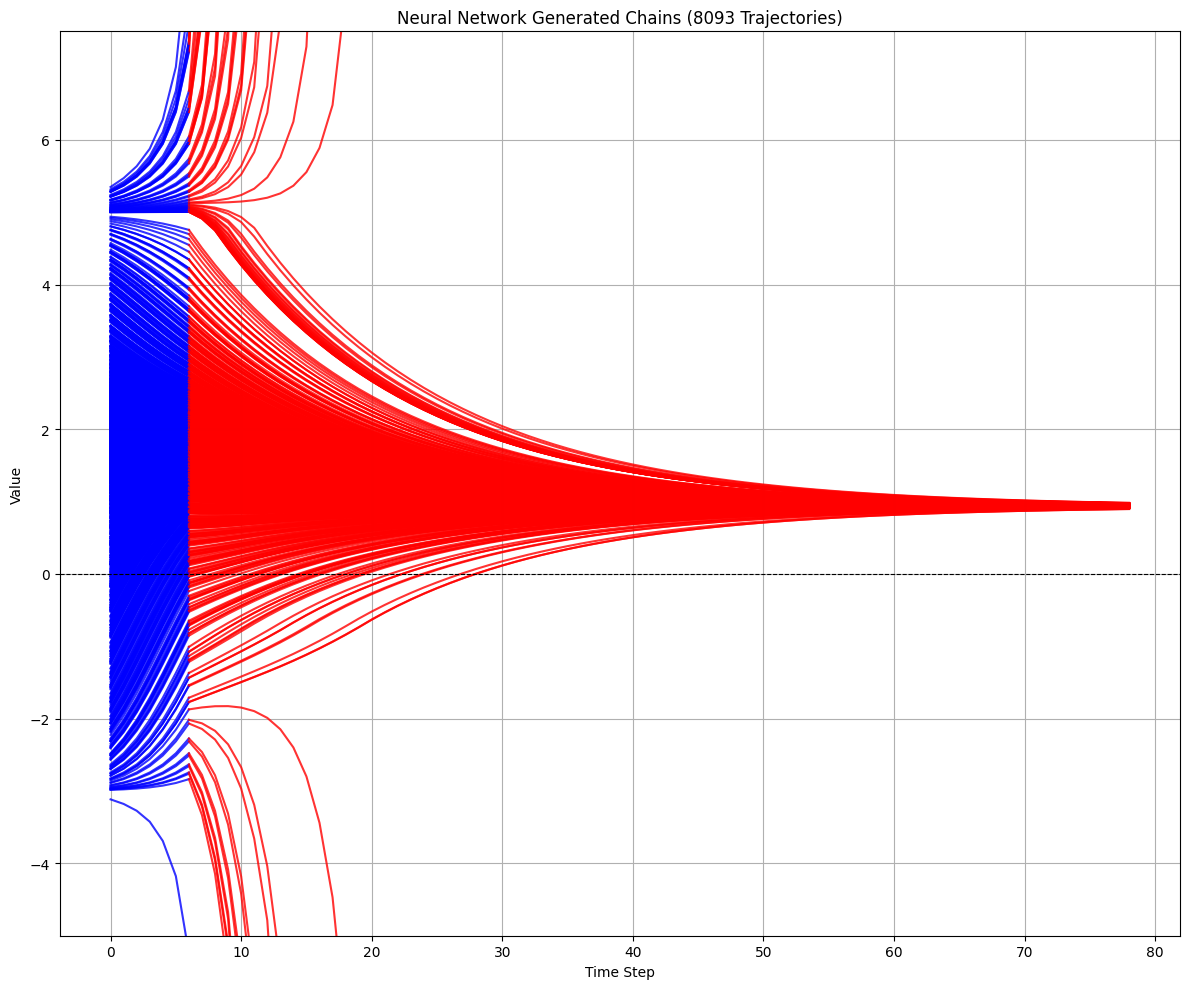

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.polynomial import Polynomial
import torch
import torch.nn as nn
import math
from torch.nn import functional as F
import time

# ========== Generate Ground Truth Data ==========
# f(x) = x^3 - 4x^2 - 11x + 30
# System has 3 equilibria at [-3, 2, 5]. -3 and 5 are unstable, 2 is stable
coeffs = [30, -11, -4, 1]
poly = Polynomial(coeffs)

def f(x):
    return poly(x)

def polyDyn1d(t, y):
    return f(y)

t_span = (0, 0.8)
t_eval = np.linspace(*t_span, 80)
x0_min, x0_max = -6.0, 6.0
n_trajectories_target = 120
min_length = 7

solutions = []
all_trajectories = []
rejected_count = 0

print("Generating ground truth trajectories...")
while len(all_trajectories) < n_trajectories_target:
    x0 = np.random.uniform(-4.0, 6.0)
    solution = solve_ivp(polyDyn1d, t_span, [x0], t_eval=t_eval)
    if len(solution.y[0]) >= min_length:
        all_trajectories.append(solution.y[0])
        solutions.append(solution)
    else:
        rejected_count += 1
        
print(f"Successfully generated {len(all_trajectories)} valid trajectories.")
print(f"Rejected {rejected_count} short trajectories during generation.")

#========== Create Test Dataset ==========
block_size = 7

test_inputs = []
test_targets = []

for i in range(len(all_trajectories)):
    trajectory = all_trajectories[i]
    for j in range(len(trajectory) - block_size):
        test_inputs.append(trajectory[j:j+block_size])
        test_targets.append(trajectory[j+block_size])

test_inputs = np.array(test_inputs)
test_targets = np.array(test_targets)

print(f"Created {len(test_inputs)} test samples from {len(all_trajectories)} trajectories")


# ========== Model Hyperparameters (must match training) ==========
n_embd = 5
num_heads = 1
head_size = n_embd // num_heads
dropout_rate = 0.2

# ========== Load Checkpoint ==========
checkpoint = torch.load('1d_transformer.pt', weights_only=False)

# ========== Recreate Model Architecture ==========
embed = nn.Linear(1, n_embd, bias=False)
w_key = nn.Linear(n_embd, head_size, bias=False)
w_query = nn.Linear(n_embd, head_size, bias=False)
w_value = nn.Linear(n_embd, head_size, bias=False)
w_attn_output = nn.Linear(head_size * num_heads, n_embd, bias=False)
dropout = nn.Dropout(dropout_rate)
norm_attn_gain = nn.Parameter(torch.ones(n_embd))
norm_attn_bias = nn.Parameter(torch.zeros(n_embd))
w_ffn = nn.Linear(n_embd, 4 * n_embd)
w_ffn_output = nn.Linear(4 * n_embd, n_embd)
norm_logits_gain = nn.Parameter(torch.ones(n_embd))
norm_logits_bias = nn.Parameter(torch.zeros(n_embd))
w_logits_output = nn.Linear(n_embd, 1)

# ========== Load Trained Weights ==========
embed.weight.data = checkpoint['embed_weight']
w_key.weight.data = checkpoint['w_key_weight']
w_query.weight.data = checkpoint['w_query_weight']
w_value.weight.data = checkpoint['w_value_weight']
w_attn_output.weight.data = checkpoint['w_attn_output_weight']
norm_attn_gain.data = checkpoint['norm_attn_gain']
norm_attn_bias.data = checkpoint['norm_attn_bias']
w_ffn.weight.data = checkpoint['w_ffn_weight']
w_ffn.bias.data = checkpoint['w_ffn_bias']
w_ffn_output.weight.data = checkpoint['w_ffn_output_weight']
w_ffn_output.bias.data = checkpoint['w_ffn_output_bias']
norm_logits_gain.data = checkpoint['norm_logits_gain']
norm_logits_bias.data = checkpoint['norm_logits_bias']
w_logits_output.weight.data = checkpoint['w_logits_output_weight']
w_logits_output.bias.data = checkpoint['w_logits_output_bias']

print("Model and weights loaded successfully!")

# ========== Set Model to Evaluation Mode ==========
embed.eval()
dropout.eval()

# ========== Run Inference ==========
indices = np.random.permutation(len(test_inputs))
shuffled_test_inputs = [test_inputs[i] for i in indices]

chains = []
print(f"\nStarting inference on {len(shuffled_test_inputs)} chains...")
print("=" * 60)
start_time = time.time()

with torch.no_grad():
    j = 0
    for idx, test_input in enumerate(shuffled_test_inputs):
        # Print progress every 100 chains
        if (idx + 1) % 100 == 0:
            elapsed = time.time() - start_time
            chains_per_sec = (idx + 1) / elapsed
            remaining = (len(shuffled_test_inputs) - idx - 1) / chains_per_sec
            print(f"Progress: {idx + 1}/{len(shuffled_test_inputs)} chains "
                  f"({100 * (idx + 1) / len(shuffled_test_inputs):.1f}%) | "
                  f"Speed: {chains_per_sec:.1f} chains/s | "
                  f"ETA: {remaining:.1f}s")
        
        chain = test_input.tolist()
        chains.append(chain)
        cancel = False
        i = block_size + 1
        prediction = 0
        
        while i < 80 and cancel == False:
            test_input_sequence = torch.tensor(test_input, dtype=torch.float32)
            test_input_data = test_input_sequence[:block_size]
            test_input_data = test_input_data.unsqueeze(-1)
            test_target = test_input_sequence[-1]
            
            # Forward pass
            test_embedded_input = embed(test_input_data)
            K, Q, V = w_key(test_embedded_input), w_query(test_embedded_input), w_value(test_embedded_input)
            raw_attention_scores = (Q @ K.transpose(-2,-1)) * (1.0 / math.sqrt(head_size))
            attention_probabilities = F.softmax(raw_attention_scores, dim=-1)
            attention_output = w_attn_output(attention_probabilities @ V)
            
            FFN_in_raw = attention_output + test_embedded_input
            FFN_in_normalized = norm_attn_gain * (FFN_in_raw - FFN_in_raw.mean(dim=-1, keepdim=True)) + norm_attn_bias
            
            FFN_activations = F.relu(w_ffn(FFN_in_normalized))
            FFN_output = w_ffn_output(FFN_activations)
            
            logits_raw = FFN_output + FFN_in_normalized
            logits_normalized = norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + norm_logits_bias
            
            logits = w_logits_output(logits_normalized)
            prediction = logits[-1, 0].item()
            
            # Update chain
            chain = chain[1:]
            chain.append(prediction)
            chains[j].append(prediction)
            test_input = torch.tensor(chain[-block_size:], dtype=torch.float32)
            i += 1
                
            if prediction < -5 or prediction > 7.5:
                cancel = True
        j += 1

total_time = time.time() - start_time
print("=" * 60)
print(f"Inference complete! Generated {len(chains)} chains in {total_time:.2f}s")
print(f"Average speed: {len(chains) / total_time:.2f} chains/s")

# ========== Visualize Results ==========
fig, ax1 = plt.subplots(1, figsize=(12, 10))
for chain in chains:
    t = np.arange(len(chain))
    ax1.plot(t[:block_size], chain[:block_size], color='blue', alpha=0.8)
    ax1.plot(t[block_size-1:], chain[block_size-1:], color='red', alpha=0.8)

ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_title(f"Neural Network Generated Chains ({len(chains)} Trajectories)")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Value")
ax1.grid()
ax1.set_ylim(-5, 7.5)
plt.tight_layout()
plt.show()

In [16]:
import random
import numpy as np
from sklearn import linear_model as lm
import copy
import matplotlib.pyplot as plt

dimension_5_total = 0
total_dimensions = 0
def batched_inference(inputs_array):
    # Convert entire batch to tensor at once (Batch_Size, Seq_Len)
    # Shape: (N, 6) -> (N, 6, 1)
    batch_input = torch.tensor(inputs_array, dtype=torch.float32).unsqueeze(-1)
    
    with torch.no_grad():
        # Embed entire batch
        emb = embed(batch_input)
        
        # Attention (Batched)
        K, Q, V = w_key(emb), w_query(emb), w_value(emb)
        raw_attn = (Q @ K.transpose(-2, -1)) * (1.0 / math.sqrt(head_size))
        attn_probs = F.softmax(raw_attn, dim=-1)
        attn_out = w_attn_output(attn_probs @ V)
        
        # FFN (Batched)
        ffn_in = attn_out + emb
        # Normalize: calculate mean over last dimension (embedding dim)
        ffn_in_norm = norm_attn_gain * (ffn_in - ffn_in.mean(dim=-1, keepdim=True)) + norm_attn_bias
        ffn_out = w_ffn_output(F.relu(w_ffn(ffn_in_norm)))
        
        # Output Logits (Batched)
        logits_raw = ffn_out + ffn_in_norm
        logits_norm = norm_logits_gain * (logits_raw - logits_raw.mean(dim=-1, keepdim=True)) + norm_logits_bias
        logits = w_logits_output(logits_norm)
        
        # Take the last prediction for every item in the batch
        # Shape: (N, Seq_Len, 1) -> select last in seq -> (N, 1) -> flatten
        predictions = logits[:, -1, 0].numpy()
        
    return predictions

def get_data(box, train_point_num, test_point_num):
    total_points = train_point_num + test_point_num
    
    # 1. Vectorized Random Generation (No loops!)
    # Create arrays of low/high bounds for the box
    lows = np.array([b[0] for b in box])
    highs = np.array([b[1] for b in box])
    
    # Generate (Total_Points, Dimensions) array
    points_x = np.random.uniform(lows, highs, size=(total_points, len(box)))
    
    # 2. Run Batched Inference (15,000 points in one pass)
    points_y = batched_inference(points_x)
    
    # 3. Split and Return
    return (points_x[:train_point_num], points_y[:train_point_num], 
            points_x[test_point_num:], points_y[test_point_num:])

def train_test_model(train_points_x, train_points_y, test_points_x, test_points_y):
    my_model = lm.LinearRegression()
    my_model.fit(train_points_x, train_points_y)
    max_error = 0
    for i, test_point_x in enumerate(test_points_x):
        predicted_y = my_model.predict([test_point_x])
        error = abs(predicted_y[0] - test_points_y[i])
        if error > max_error:
            max_error = error
    return max_error, my_model
    

def choose_split(box, train_point_num, test_point_num):
    min_error = np.inf
    best_box_model_pairs = []
    best_dimension = -1
    for dimension in range(len(box)):
        min_range, max_range = box[dimension]
        divider = (min_range + max_range) / 2
        box1 = copy.deepcopy(box)
        box1[dimension] = [divider, max_range]
        box2 = copy.deepcopy(box)
        box2[dimension] = [min_range, divider]
        train_points_x1, train_points_y1, test_points_x1, test_points_y1 = get_data(box1, train_point_num, test_point_num)
        error1, model1 = train_test_model(train_points_x1, train_points_y1, test_points_x1, test_points_y1)
        train_points_x2, train_points_y2, test_points_x2, test_points_y2 = get_data(box2, train_point_num, test_point_num)
        error2, model2 = train_test_model(train_points_x2, train_points_y2, test_points_x2, test_points_y2)
        if error1 + error2 < min_error:
            min_error = error1 + error2
            best_box_model_pairs = [{"box": box1, "model": model1}, {"box": box2, "model": model2}]
            best_dimension = dimension
    print(f"Chose to split dimension {best_dimension} with combined error {min_error}")
    return best_box_model_pairs

def split_box_pair(box):
    box_model_pairs = choose_split(box, 100, 0)
    return split_box(box_model_pairs[0]["box"]) + split_box(box_model_pairs[1]["box"])

def split_box(box):
    fast_check_N = 100
    X_fast, y_fast, _, _ = get_data(box, fast_check_N, 0)
    model_fast = lm.LinearRegression()
    model_fast.fit(X_fast, y_fast)
    preds_fast = model_fast.predict(X_fast)
    if np.max(np.abs(preds_fast - y_fast)) > epsilon:
        return split_box_pair(box)

    X_full, y_full, _, _ = get_data(box, N, 0) 
    model_full = lm.LinearRegression()
    model_full.fit(X_full, y_full)
    preds_full = model_full.predict(X_full)
    max_error = np.max(np.abs(preds_full - y_full))
    if max_error < epsilon:
        print(f"✓ CERTIFIED Box with {N} samples. Max error: {max_error:.5f}")
        return [{"box": box, "model": model_full}]
    else:
        print(f"✗ Failed rigorous test (Error: {max_error:.5f}). Splitting...")
        return split_box_pair(box)

c = 0.95   # Confidence level
p = 0.99   # Probability correct
numerator = -math.log(1 - c)
denominator = 2 * ((1 - p) ** 2)
N = math.ceil(numerator / denominator)
print(f"Calculated Sample Size N: {N}")
test_point_num = N   
train_point_num = N
epsilon = 0.1
block_size = 7
box = np.tile([-3, 3], (block_size - 1, 1)).tolist()
box_model_pairs = split_box(box)
print(f"Generated {len(box_model_pairs)} boxes with models")

Calculated Sample Size N: 14979
Chose to split dimension 5 with combined error 0.38423779518343326
✓ CERTIFIED Box with 14979 samples. Max error: 0.03057
Chose to split dimension 5 with combined error 0.4488204126731592
Chose to split dimension 5 with combined error 0.19819280119073313
✗ Failed rigorous test (Error: 0.14450). Splitting...
Chose to split dimension 5 with combined error 0.060719832463351275
✓ CERTIFIED Box with 14979 samples. Max error: 0.07476
✗ Failed rigorous test (Error: 0.11835). Splitting...
Chose to split dimension 5 with combined error 0.05657947248183981
✓ CERTIFIED Box with 14979 samples. Max error: 0.07081
✗ Failed rigorous test (Error: 0.11846). Splitting...
Chose to split dimension 3 with combined error 0.041829697284150535
✗ Failed rigorous test (Error: 0.11687). Splitting...
Chose to split dimension 5 with combined error 0.02706949178057949
✓ CERTIFIED Box with 14979 samples. Max error: 0.06933
✗ Failed rigorous test (Error: 0.10900). Splitting...
Chose to

OVERLAP ANALYSIS

Total number of boxes: 385
Number of overlapping pairs: 0

✓ SUCCESS: No overlapping boxes found!

COVERAGE STATISTICS

Initial domain volume: 46656.000000
Total volume of all boxes: 46656.000000
Coverage ratio: 1.0000

DIMENSION COVERAGE

Dimension 0:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 1:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 2:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 3:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 4:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved

Dimension 5:
  Target range: [-3, 3]
  Actual coverage: [-3.0000, 3.0000]
  ✓ Full coverage achieved


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_50450/3616894666.py:126: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle(center, radius, alpha=0.3, color='blue', edgecolor='black', linewidth=0.5)


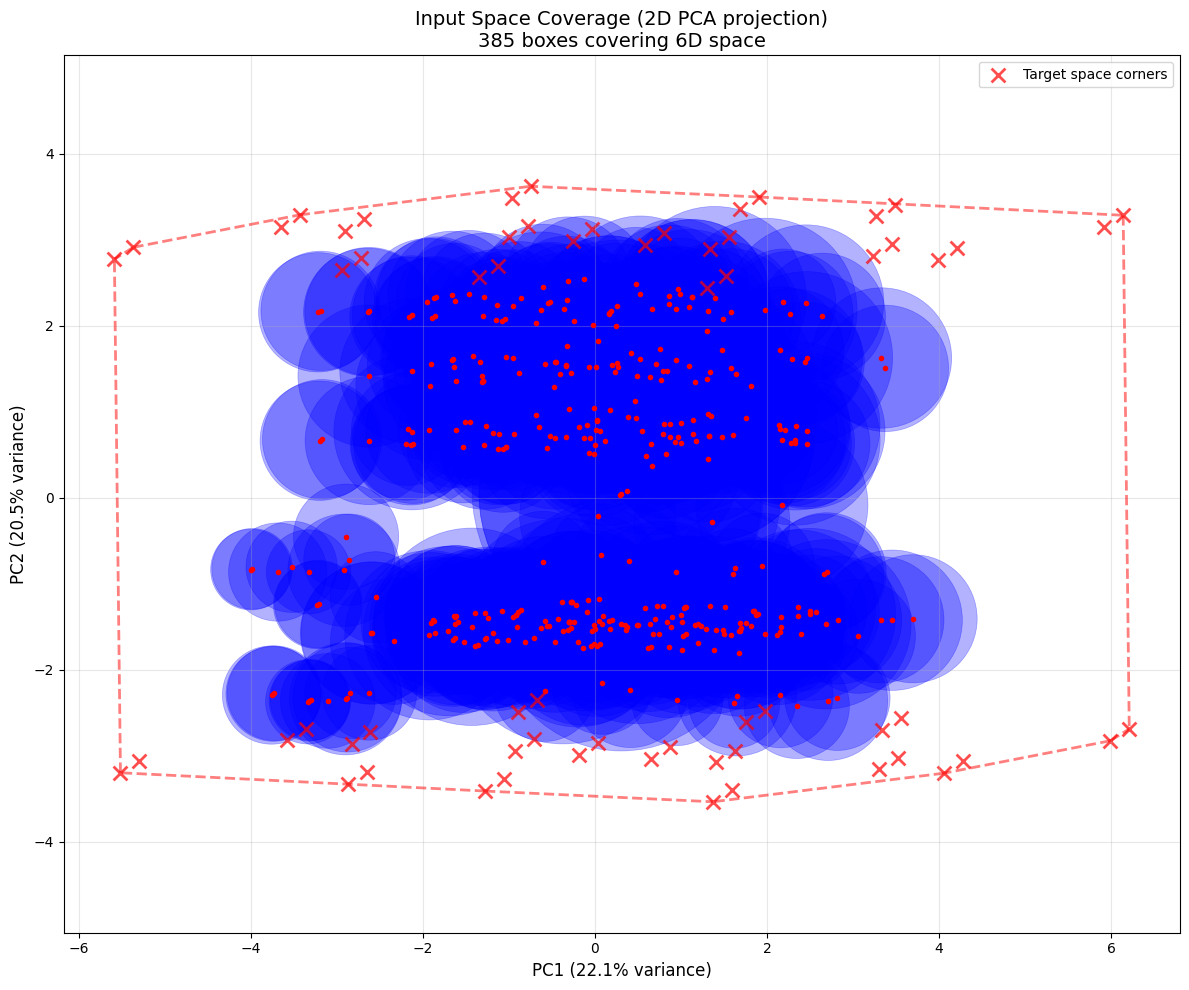


Total variance explained by 2D projection: 42.6%
Number of boxes: 385
Dimensions: 6

PCA Component 1 weights:
  Dimension 0: 0.448
  Dimension 1: 0.322
  Dimension 2: 0.441
  Dimension 3: -0.012
  Dimension 4: 0.707
  Dimension 5: 0.037

PCA Component 2 weights:
  Dimension 0: 0.055
  Dimension 1: 0.063
  Dimension 2: -0.021
  Dimension 3: 0.995
  Dimension 4: -0.035
  Dimension 5: 0.023


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_50450/3616894666.py:185: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle((center_j - size_j, center_i - size_i),


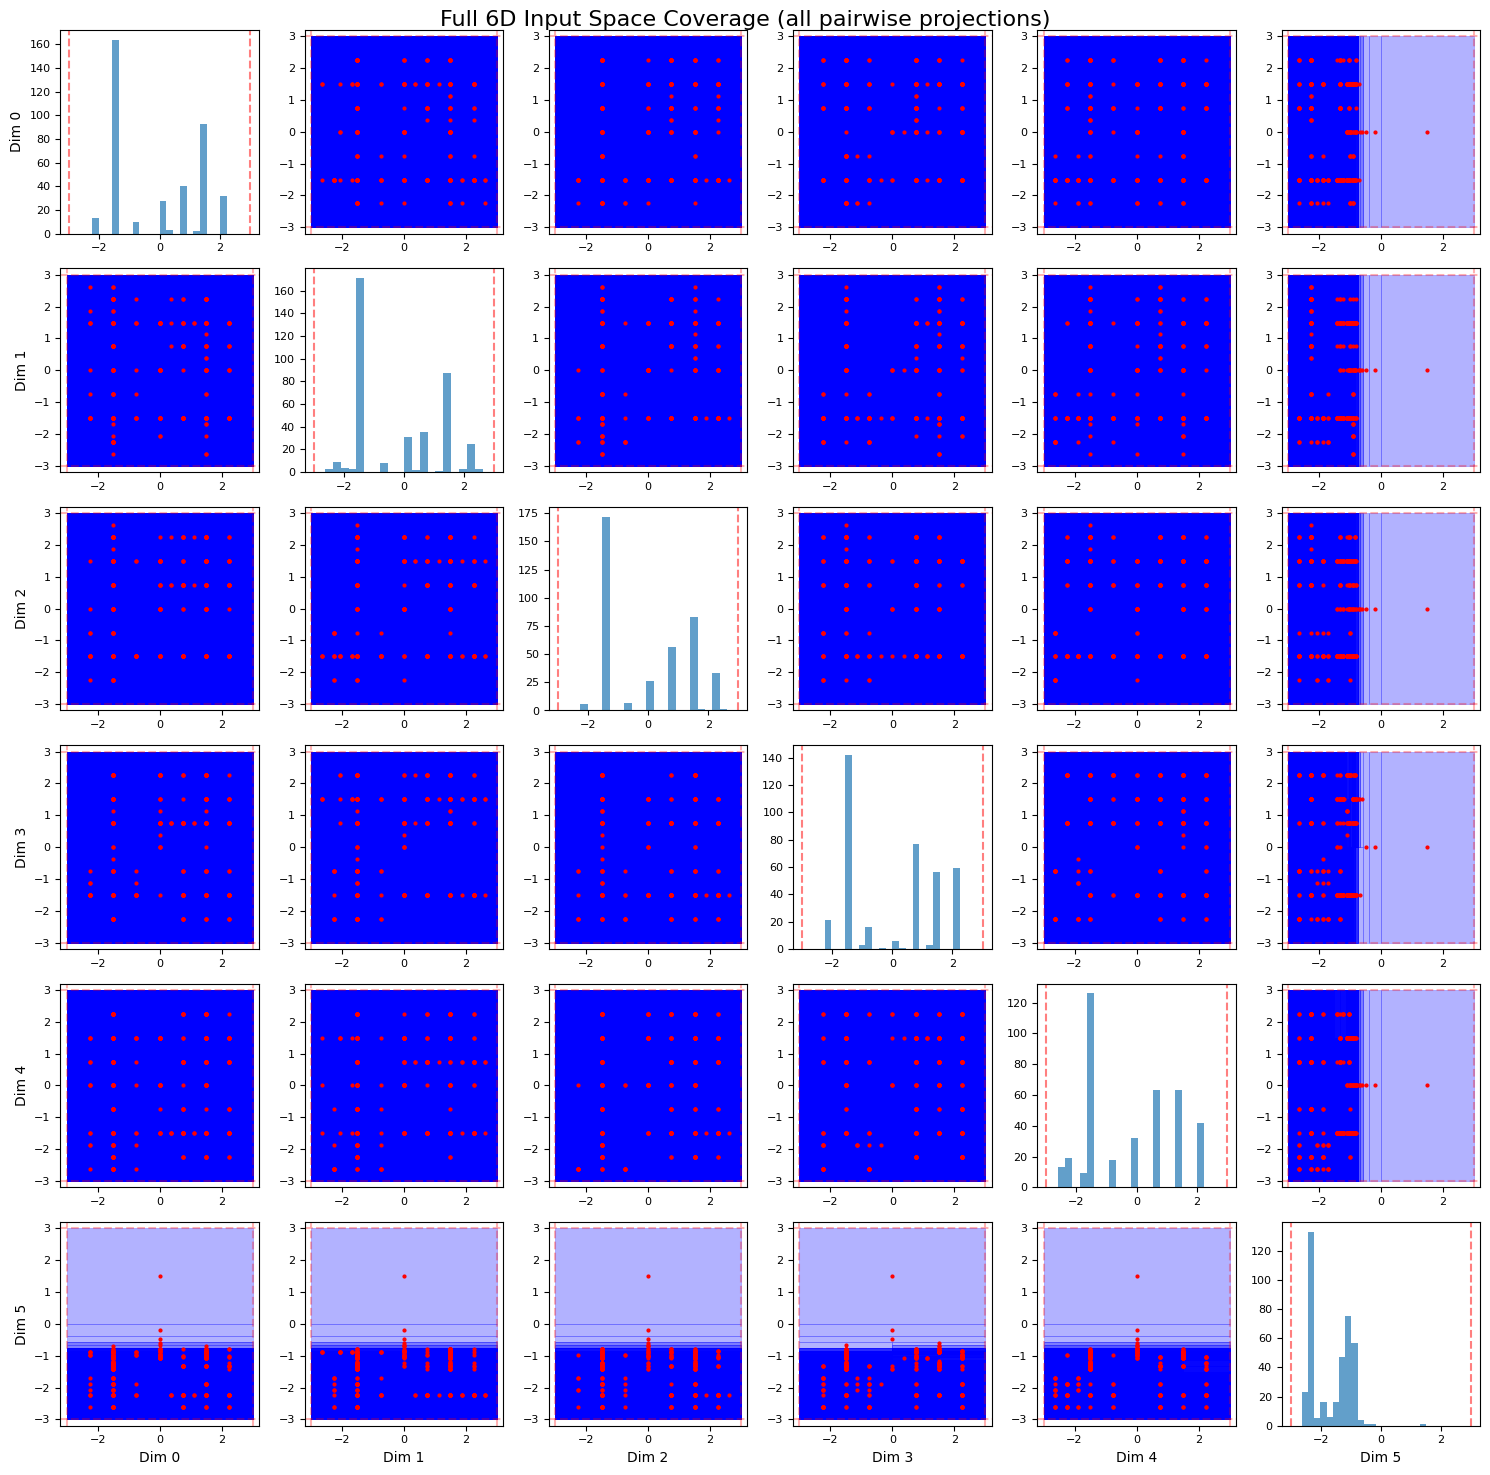

In [17]:
boxes = [pair["box"] for pair in box_model_pairs]
range_to_cover = [-3, 3]

def boxes_overlap(box1, box2):
    for dim in range(len(box1)):
        min1, max1 = box1[dim]
        min2, max2 = box2[dim]
        if max1 <= min2 or max2 <= min1:
            return False
    return True

def check_all_overlaps(boxes):
    overlapping_pairs = []
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            if boxes_overlap(boxes[i], boxes[j]):
                overlapping_pairs.append((i, j))
    
    return overlapping_pairs

def calculate_overlap_volume(box1, box2):
    if not boxes_overlap(box1, box2):
        return 0.0
    
    overlap_volume = 1.0
    for dim in range(len(box1)):
        min1, max1 = box1[dim]
        min2, max2 = box2[dim]
        overlap_min = max(min1, min2)
        overlap_max = min(max1, max2)
        overlap_length = overlap_max - overlap_min
        
        overlap_volume *= overlap_length
    
    return overlap_volume

def calculate_box_volume(box):
    volume = 1.0
    for dim_range in box:
        volume *= (dim_range[1] - dim_range[0])
    return volume

print("=" * 60)
print("OVERLAP ANALYSIS")
print("=" * 60)

overlapping_pairs = check_all_overlaps(boxes)

print(f"\nTotal number of boxes: {len(boxes)}")
print(f"Number of overlapping pairs: {len(overlapping_pairs)}")

if len(overlapping_pairs) == 0:
    print("\n✓ SUCCESS: No overlapping boxes found!")
else:
    print(f"\n✗ WARNING: Found {len(overlapping_pairs)} overlapping pairs")

    print("\nFirst 5 overlapping pairs (if any):")
    for idx, (i, j) in enumerate(overlapping_pairs[:5]):
        overlap_vol = calculate_overlap_volume(boxes[i], boxes[j])
        vol_i = calculate_box_volume(boxes[i])
        vol_j = calculate_box_volume(boxes[j])
        print(f"\nPair {idx + 1}: Box {i} and Box {j}")
        print(f"  Overlap volume: {overlap_vol:.6f}")
        print(f"  Box {i} volume: {vol_i:.6f}")
        print(f"  Box {j} volume: {vol_j:.6f}")
        print(f"  Overlap as % of box {i}: {100 * overlap_vol / vol_i:.2f}%")
        print(f"  Overlap as % of box {j}: {100 * overlap_vol / vol_j:.2f}%")

print("\n" + "=" * 60)
print("COVERAGE STATISTICS")
print("=" * 60)

total_volume = sum(calculate_box_volume(box) for box in boxes)
initial_volume = calculate_box_volume([[-3, 3]] * (block_size - 1))

print(f"\nInitial domain volume: {initial_volume:.6f}")
print(f"Total volume of all boxes: {total_volume:.6f}")
print(f"Coverage ratio: {total_volume / initial_volume:.4f}")

if len(overlapping_pairs) > 0:
    total_overlap = sum(calculate_overlap_volume(boxes[i], boxes[j]) 
                       for i, j in overlapping_pairs)
    print(f"Total overlap volume: {total_overlap:.6f}")
    print(f"Overlap as % of total: {100 * total_overlap / total_volume:.2f}%")

print("\n" + "=" * 60)
print("DIMENSION COVERAGE")
print("=" * 60)

for dim in range(block_size - 1):
    dim_mins = [box[dim][0] for box in boxes]
    dim_maxs = [box[dim][1] for box in boxes]
    
    coverage_min = min(dim_mins)
    coverage_max = max(dim_maxs)
    
    print(f"\nDimension {dim}:")
    print(f"  Target range: [{range_to_cover[0]}, {range_to_cover[1]}]")
    print(f"  Actual coverage: [{coverage_min:.4f}, {coverage_max:.4f}]")
    
    if coverage_min > range_to_cover[0]:
        print(f"  ⚠ Gap at lower end: {coverage_min - range_to_cover[0]:.4f}")
    if coverage_max < range_to_cover[1]:
        print(f"  ⚠ Gap at upper end: {range_to_cover[1] - coverage_max:.4f}")
    if coverage_min <= range_to_cover[0] and coverage_max >= range_to_cover[1]:
        print(f"  ✓ Full coverage achieved")

from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

box_centers = np.array([[(box[dim][0] + box[dim][1]) / 2 for dim in range(len(box))] 
                        for box in boxes])
box_sizes = np.array([[(box[dim][1] - box[dim][0]) / 2 for dim in range(len(box))] 
                      for box in boxes])


pca = PCA(n_components=2)
centers_2d = pca.fit_transform(box_centers)

plt.figure(figsize=(12, 10))

for i, (center, box_size) in enumerate(zip(centers_2d, box_sizes)):
    avg_size = np.mean(box_size)
    radius = avg_size * np.sqrt(np.sum(pca.explained_variance_ratio_))
    
    circle = plt.Circle(center, radius, alpha=0.3, color='blue', edgecolor='black', linewidth=0.5)
    plt.gca().add_patch(circle)
    plt.plot(center[0], center[1], 'ro', markersize=3)

n_dims = len(boxes[0])
corner_points = []
for i in range(2**n_dims):
    corner = [range_to_cover[0] if (i >> j) & 1 == 0 else range_to_cover[1] 
              for j in range(n_dims)]
    corner_points.append(corner)
corners_2d = pca.transform(corner_points)

try:
    hull = ConvexHull(corners_2d)
    for simplex in hull.simplices:
        plt.plot(corners_2d[simplex, 0], corners_2d[simplex, 1], 'r--', alpha=0.5, linewidth=2)
except:
    pass

plt.scatter(corners_2d[:, 0], corners_2d[:, 1], c='red', marker='x', s=100, 
            label='Target space corners', alpha=0.7, linewidths=2)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'Input Space Coverage (2D PCA projection)\n{len(boxes)} boxes covering {n_dims}D space', fontsize=14)
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTotal variance explained by 2D projection: {sum(pca.explained_variance_ratio_):.1%}")
print(f"Number of boxes: {len(boxes)}")
print(f"Dimensions: {n_dims}")

print("\nPCA Component 1 weights:")
for i, weight in enumerate(pca.components_[0]):
    print(f"  Dimension {i}: {weight:.3f}")
print("\nPCA Component 2 weights:")
for i, weight in enumerate(pca.components_[1]):
    print(f"  Dimension {i}: {weight:.3f}")

fig, axes = plt.subplots(6, 6, figsize=(15, 15))

for i in range(6):
    for j in range(6):
        ax = axes[i, j]
        if i == j:
            midpoints = [(box[i][0] + box[i][1]) / 2 for box in boxes]
            ax.hist(midpoints, bins=20, alpha=0.7)
            ax.axvline(range_to_cover[0], color='red', linestyle='--', alpha=0.5)
            ax.axvline(range_to_cover[1], color='red', linestyle='--', alpha=0.5)
        else:
            for box in boxes:
                center_i = (box[i][0] + box[i][1]) / 2
                center_j = (box[j][0] + box[j][1]) / 2
                size_i = (box[i][1] - box[i][0]) / 2
                size_j = (box[j][1] - box[j][0]) / 2
                
                rect = plt.Rectangle((center_j - size_j, center_i - size_i), 
                                    2 * size_j, 2 * size_i, 
                                    alpha=0.3, color='blue', edgecolor='black', linewidth=0.5)
                ax.add_patch(rect)
                ax.plot(center_j, center_i, 'ro', markersize=2)
            

            ax.axhline(range_to_cover[0], color='red', linestyle='--', alpha=0.3)
            ax.axhline(range_to_cover[1], color='red', linestyle='--', alpha=0.3)
            ax.axvline(range_to_cover[0], color='red', linestyle='--', alpha=0.3)
            ax.axvline(range_to_cover[1], color='red', linestyle='--', alpha=0.3)

            ax.set_xlim(range_to_cover[0] - 0.2, range_to_cover[1] + 0.2)
            ax.set_ylim(range_to_cover[0] - 0.2, range_to_cover[1] + 0.2)
            
        if j == 0:
            ax.set_ylabel(f'Dim {i}', fontsize=10)
        if i == 5:
            ax.set_xlabel(f'Dim {j}', fontsize=10)
        
        ax.tick_params(labelsize=8)

plt.suptitle('Full 6D Input Space Coverage (all pairwise projections)', fontsize=16)
plt.tight_layout()
plt.show()

# Probability Metrics For Each Box

<img src="archive/binomial.png" />

In [8]:
# "I checked N points and they were all inside the tube; therefore, with high probability, the entire model is inside the tube."
# ========== Probability Metrics (Hoeffding) ==========
confidence = 0.90
p_threshold = 0.90
# N >= -ln(1-c) / (2*(1-p)^2)
N = math.ceil(-math.log(1 - confidence) / (2 * (1 - p_threshold)**2))

print(f"Calculated required samples: {N} (for 95% conf, 99% accuracy)")
test_point_num = N
train_point_num = N

Calculated required samples: 116 (for 95% conf, 99% accuracy)


# MILP Solving

In [ ]:
import gurobipy as gp
from gurobipy import GRB


m = gp.Model("Piecewise_Linear_Optimization")
# input = 6d point in range, output = 1 variable to minimize
x = m.addVars(block_size - 1, lb=range_to_cover[0], ub=range_to_cover[1], name="x", vtype=GRB.CONTINUOUS)
y = m.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, name="y", vtype=GRB.CONTINUOUS)
# z[i] = 1 if we are in region i
z = m.addVars(len(box_model_pairs), vtype=GRB.BINARY, name="z")


# sum of all binary switches must be 1, x inside box i if z[i] is active
m.addConstr(z.sum() == 1)
for i, pair in enumerate(box_model_pairs):
    box = pair["box"]
    model = pair["model"]
    for dimension in range(block_size - 1):
        min_range, max_range = box[dimension]
        m.addGenConstrIndicator(z[i], True, x[dim] >= min_range)
        m.addGenConstrIndicator(z[i], True, x[dim] <= max_range)
    # if x in box, x bounded by linear model
    coeffs, intercept = model.coef_, model.intercept_
    linear_pred = intercept + gp.quicksum(coeffs[j] * x[j] for j in range(block_size - 1))
    m.addGenConstrIndicator(z[i], True, y >= linear_pred - epsilon)
    m.addGenConstrIndicator(z[i], True, y <= linear_pred + epsilon)

m.setObjective(y, GRB.MINIMIZE)
m.optimize()
if m.status == GRB.OPTIMAL:
    min_y = y.X
    best_x = [x[k].X for k in range(block_size - 1)]
    active_region = [k for k in range(len(box_model_pairs)) if z[k].X > 0.5][0]
    print(f"Found Global Min y: {min_y:.4f}")
    print(f"Location x: {best_x}")
else:
    print("Optimization failed or infeasible")
m.setObjective(y, GRB.MAXIMIZE)
m.optimize()
if m.status == GRB.OPTIMAL:
    max_y = y.X
    best_x = [x[k].X for k in range(block_size - 1)]
    active_region = [k for k in range(len(box_model_pairs)) if z[k].X > 0.5][0]
    print(f"Found Global Max y: {max_y:.4f}")
    print(f"Location x: {best_x}")
else:
    print("Optimization failed or infeasible")

In [19]:

def check_property(box_model_pairs, input_range, objective_expr_type="value"):
    model = gp.Model("Verifier")
    total_dimensions = len(box_model_pairs[0]["box"])
    
    input_variables = model.addVars(
        total_dimensions,
        lb=input_range[0],
        ub=input_range[1],
        vtype=GRB.CONTINUOUS
    )
    output_variables = model.addVar(
        lb=-GRB.INFINITY,
        ub=GRB.INFINITY,
        vtype=GRB.CONTINUOUS
    )
    
    # You can only pick one region to cause out of bounds error
    switch_variables = model.addVars(len(box_model_pairs), vtype=GRB.BINARY)
    model.addConstr(switch_variables.sum() == 1)
    
    # Constraints
    for i, pair in enumerate(box_model_pairs):
        box = pair["box"]
        linear_model = pair["model"]
        box_error = pair.get("error", epsilon)
        
        # Input var must be inside current box
        for dim in range(total_dimensions):
            model.addGenConstrIndicator(
                switch_variables[i], True, input_variables[dim] >= box[dim][0]
            )
            model.addGenConstrIndicator(
                switch_variables[i], True, input_variables[dim] <= box[dim][1]
            )
        
        # Output var must match current linear model
        coeffs, intercept = linear_model.coef_, linear_model.intercept_
        linear_regression_prediction = intercept + gp.quicksum(
            coeffs[j] * input_variables[j] for j in range(total_dimensions)
        )
        model.addGenConstrIndicator(
            switch_variables[i], True, output_variables >= linear_regression_prediction - box_error
        )
        
        # UPPER BOUND: y <= (Wx + b) + error
        model.addGenConstrIndicator(
            switch_variables[i], True, output_variables <= linear_regression_prediction + box_error
        )
    
    # Define Objective
    objective = output_variables
    x_last = input_variables[total_dimensions - 1]
    if objective_expr_type == "delta":
        objective = output_variables - x_last  # Make sure this value is always negative
    
    # --- SOLVE FOR MAX ---
    model.setObjective(objective, GRB.MAXIMIZE)
    model.optimize()
    max_val = model.objVal if model.status == GRB.OPTIMAL else None
    max_x = (
        [input_variables[k].X for k in range(total_dimensions)]
        if model.status == GRB.OPTIMAL
        else None
    )
    
    # --- SOLVE FOR MIN ---
    model.setObjective(objective, GRB.MINIMIZE)
    model.optimize()
    min_val = model.objVal if model.status == GRB.OPTIMAL else None
    min_x = (
        [input_variables[k].X for k in range(total_dimensions)]
        if model.status == GRB.OPTIMAL
        else None
    )
    
    return max_val, max_x, min_val, min_x


# Test 1: Inputs in [-3, 5] -> Output MUST be in [-3, 5]
# Because "System has 3 equilibria at [-3, 2, 5]. -3 and 5 are unstable, 2 is stable"
# f(x) = (x - 5)(x - 2)(x + 3)
max_y, max_x, min_y, min_x = check_property(
    box_model_pairs, input_range=(-3.0, 5.0), objective_expr_type="value"
)

if max_y > 5.0:
    print(
        f"Fail. Upper bound broken. Max y={max_y:.4f} at inputs "
        f"{['%.2f' % v for v in max_x]}"
    )
else:
    print(f"Pass. Upper bound safe. (Max y={max_y:.4f})")

if min_y < -3.0:
    print(
        f"Fail. Lower bound broken. Min y={min_y:.4f} at inputs "
        f"{['%.2f' % v for v in min_x]}"
    )
else:
    print(f"Pass. Lower bound safe (Min y={min_y:.4f})")

print("Transformer model also broken: " + str(single_inference_point(min_x)))

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M2 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 1 rows, 392 columns and 385 nonzeros
Model fingerprint: 0x910272db
Model has 5390 simple general constraints
  5390 INDICATOR
Variable types: 7 continuous, 385 integer (385 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 5e+00]
  RHS range        [1e+00, 1e+00]
  GenCon rhs range [5e-03, 3e+00]
  GenCon coe range [7e-07, 2e+00]
Presolve added 782 rows and 770 columns
Presolve time: 0.05s
Presolved: 783 rows, 1162 columns, 9338 nonzeros
Presolved model has 770 SOS constraint(s)
Variable types: 777 continuous, 385 integer (385 binary)
Found heuristic solution: objective 2.9433952

Root relaxation: unbounded, 388 iterations, 0.00 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objecti

In [20]:
# Test 2: Inputs in [2, 5] must be decreasing over time
max_delta, max_x, _, _ = check_property(
    box_model_pairs, input_range=(2.1, 4.9), objective_expr_type="delta"
)

if max_delta > 0:
    print(
        f"Fail. Wrong flow direction! Model grew by {max_delta:.4f} at inputs "
        f"{['%.2f' % v for v in max_x]}"
    )
else:
    print(f"Pass. Flow direction correct (Max growth={max_delta:.4f})")


# Test 3: Inputs in [-2.9, 1.9] -> delta (y - x_last) MUST be POSITIVE (should grow)
_, _, min_delta, min_x = check_property(
    box_model_pairs, input_range=(-2.9, 1.9), objective_expr_type="delta"
)

if min_delta < 0:
    print(
        f"Fail. Wrong flow direction! Model shrank by {min_delta:.4f} at inputs "
        f"{['%.2f' % v for v in min_x]}"
    )
else:
    print(f"Pass. Flow direction correct (Min growth={min_delta:.4f})")

Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M2 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 1 rows, 392 columns and 385 nonzeros
Model fingerprint: 0x647898fa
Model has 5390 simple general constraints
  5390 INDICATOR
Variable types: 7 continuous, 385 integer (385 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 5e+00]
  RHS range        [1e+00, 1e+00]
  GenCon rhs range [5e-03, 3e+00]
  GenCon coe range [7e-07, 2e+00]
Presolve removed 1 rows and 392 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.01 work units)
Thread count was 1 (of 10 available processors)

Solution count 1: 0.0200759 
No other solutions better than 0.0200759

Optimal solution found (tolerance 1.00e-04)
Best objective 2.007588308192e-02, best 